In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 1. Load your results =====
# Replace with actual values from your provided tables
train_data = {
    "Entity": [
        "CustomerReportedSymptom","DeviceProperties","EquipmentName","FaultCode",
        "FaultType","MaintenanceMethod","MeasurementValue","TimeDuration",
        "VehicleComponentLocation","VehicleMakeModel"
    ],
    "Precision": [1]*10,
    "Recall": [1]*10,
    "F1": [1]*10
}

gliner_data = {
    "Entity": [
        "CustomerReportedSymptom","DeviceProperties","EquipmentName","FaultCode",
        "FaultType","MaintenanceMethod","MeasurementValue","TimeDuration",
        "VehicleComponentLocation","VehicleMakeModel"
    ],
    "Precision": [0.36,0.09,0.69,0.66,0.58,0.16,0.15,0.15,0.17,0.00],
    "Recall": [0.01,0.02,0.10,0.62,0.54,0.18,0.15,0.17,0.17,0.00],
    "F1": [0.03,0.03,0.17,0.64,0.56,0.17,0.15,0.16,0.17,0.00]
}

gold_data = {
    "Entity": [
        "CustomerReportedSymptom","DeviceProperties","EquipmentName","FaultCode",
        "FaultType","MaintenanceMethod","MeasurementValue","TimeDuration",
        "VehicleComponentLocation","VehicleMakeModel"
    ],
    "Precision": [0.183,0.038,0.288,0.268,0.042,0.235,0.778,0.167,0.221,0.118],
    "Recall": [0.407,0.007,0.057,0.682,0.377,0.018,0.538,0.032,0.375,1.000],
    "F1": [0.252,0.012,0.096,0.385,0.076,0.033,0.636,0.053,0.278,0.211]
}

noise_data = {
    "Entity": [
        "CustomerReportedSymptom","DeviceProperties","EquipmentName","FaultCode",
        "FaultType","MaintenanceMethod","MeasurementValue","TimeDuration",
        "VehicleComponentLocation","VehicleMakeModel"
    ],
    "Precision": [0.166,0.0,0.074,0.49,0.033,0.0,0.745,0.855,0.49,0.0],
    "Recall": [0.998,0.0,0.247,0.986,0.029,0.0,1.0,0.849,0.968,0.0],
    "F1": [0.284,0.0,0.114,0.655,0.031,0.0,0.854,0.852,0.651,0.0]
}

df_train = pd.DataFrame(train_data)
df_gliner = pd.DataFrame(gliner_data)
df_gold = pd.DataFrame(gold_data)
df_noise = pd.DataFrame(noise_data)

# ===== 2. Grouped Bar Chart: Per-entity F1 =====
df_f1 = pd.concat([
    df_train[["Entity","F1"]].assign(Model="Finetune-Train"),
    df_gliner[["Entity","F1"]].assign(Model="GLiNER"),
    df_gold[["Entity","F1"]].assign(Model="Finetune-Gold"),
    df_noise[["Entity","F1"]].assign(Model="Finetune-Noise")
])

plt.figure(figsize=(12,6))
sns.barplot(data=df_f1, x="Entity", y="F1", hue="Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0,1)
plt.title("Per-Entity F1 across Datasets")
plt.tight_layout()
plt.savefig("grouped_f1.png", dpi=300)
plt.close()

# ===== 3. ΔF1 Heatmap =====
df_delta = pd.DataFrame({
    "Entity": df_train["Entity"],
    "Train→Gold": df_gold["F1"] - df_train["F1"],
    "Train→Noise": df_noise["F1"] - df_train["F1"]
}).set_index("Entity")

plt.figure(figsize=(6,6))
sns.heatmap(df_delta, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("ΔF1 relative to Train")
plt.tight_layout()
plt.savefig("delta_f1_heatmap.png", dpi=300)
plt.close()

# ===== 4. Precision–Recall Quadrant for Noise =====
plt.figure(figsize=(6,6))
plt.axhline(0.5, color='grey', linestyle='--')
plt.axvline(0.5, color='grey', linestyle='--')
sns.scatterplot(data=df_noise, x="Recall", y="Precision", s=100)
for i, row in df_noise.iterrows():
    plt.text(row["Recall"]+0.01, row["Precision"]+0.01, row["Entity"], fontsize=8)
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Quadrant (Noise)")
plt.tight_layout()
plt.savefig("precision_recall_quadrant_noise.png", dpi=300)
plt.close()

# ===== 5. Macro vs. Micro F1 trends =====
macro_micro = pd.DataFrame({
    "Dataset": ["Finetune-Train","GLiNER","Finetune-Gold","Finetune-Noise"],
    "Macro-F1": [1.0, 0.21, 0.259, 0.381],
    "Micro-F1": [1.0, 0.22, None, None]  # Add Gold/Noise micro-F1 if available
})

plt.figure(figsize=(6,4))
sns.lineplot(data=macro_micro, x="Dataset", y="Macro-F1", marker="o", label="Macro-F1")
sns.lineplot(data=macro_micro, x="Dataset", y="Micro-F1", marker="o", label="Micro-F1")
plt.ylim(0,1)
plt.title("Macro vs. Micro F1 across Datasets")
plt.tight_layout()
plt.savefig("macro_micro_trends.png", dpi=300)
plt.close()

print("✅ Figures saved: grouped_f1.png, delta_f1_heatmap.png, precision_recall_quadrant_noise.png, macro_micro_trends.png")


✅ Figures saved: grouped_f1.png, delta_f1_heatmap.png, precision_recall_quadrant_noise.png, macro_micro_trends.png


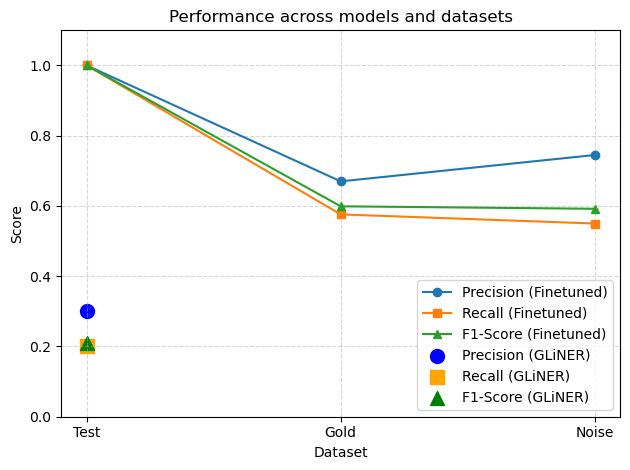

In [26]:
import matplotlib.pyplot as plt

# Datasets for Finetuned model
finetuned_datasets = ['Test', 'Gold', 'Noise']
precision_f = [1.0, 0.67, 0.745]
recall_f    = [1.0, 0.576, 0.55]
f1_f        = [1.0, 0.599, 0.592]

# GLiNER performance (only on Train set)
precision_g = [0.3]
recall_g    = [0.2]
f1_g        = [0.21]

# Plot Finetuned model
plt.plot(finetuned_datasets, precision_f, marker='o', label='Precision (Finetuned)')
plt.plot(finetuned_datasets, recall_f, marker='s', label='Recall (Finetuned)')
plt.plot(finetuned_datasets, f1_f, marker='^', label='F1-Score (Finetuned)')

# Plot GLiNER as dashed markers
plt.scatter(['Test'], precision_g, color='blue', marker='o', s=100, label='Precision (GLiNER)')
plt.scatter(['Test'], recall_g, color='orange', marker='s', s=100, label='Recall (GLiNER)')
plt.scatter(['Test'], f1_g, color='green', marker='^', s=100, label='F1-Score (GLiNER)')

plt.ylim(0, 1.1)
plt.title('Performance across models and datasets')
plt.ylabel('Score')
plt.xlabel('Dataset')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
